## Step 2 — Sentiment Analysis & Theme Extraction
**Goal:** Move beyond proxy sentiment (stars/NPS) to text-based sentiment and discover themes in customer feedback.  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import confusion_matrix, classification_report
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

sns.set(style="whitegrid")


### Load Data
Load the processed datasets prepared in Step 1.


In [2]:
df = pd.read_csv('../data/processed/processed_reviews.csv')

print(f'There are {df.shape[1]} columns, and {df.shape[0]} rows of data')

There are 16 columns, and 12495 rows of data


In [3]:
# List the columns

for col in df.columns:
    print(col)

reviewId
userName
content
score
thumbsUpCount
reviewCreatedVersion
at
replyContent
repliedAt
sortOrder
appId
detected_lang
char_len
token_len
sentiment_proxy
nps_label


### 3. Sentiment Analysis
### 3.1 VADER Baseline


In [4]:
# Initialize VADER
sid = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return "neutral"
    score = sid.polarity_scores(text)["compound"]
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

In [5]:
# Apply to Google reviews (example)
df["vader_sentiment"] = df["content"].apply(vader_sentiment)

df["vader_sentiment"].value_counts(normalize=True)


vader_sentiment
positive    0.621289
negative    0.220488
neutral     0.158223
Name: proportion, dtype: float64

### Compare VADER vs Proxy Labels


In [6]:
# Example: compare Google stars → proxy vs VADER
proxy = df["sentiment_proxy"] 
vader = df["vader_sentiment"]

print(confusion_matrix(proxy, vader))

print("\n",classification_report(proxy, vader))


[[2046 1056 1748]
 [ 452  320 1219]
 [ 257  601 4796]]

               precision    recall  f1-score   support

    negative       0.74      0.42      0.54      4850
     neutral       0.16      0.16      0.16      1991
    positive       0.62      0.85      0.71      5654

    accuracy                           0.57     12495
   macro avg       0.51      0.48      0.47     12495
weighted avg       0.59      0.57      0.56     12495



### 4. Theme Extraction
### 4.1 N-gram Exploration


In [7]:
# Separate negative reviews
neg_reviews = df[df["vader_sentiment"]=="negative"]["content"].dropna()


# Top bigrams
vectorizer = CountVectorizer(ngram_range=(1,2), stop_words="english", max_features=20)
X = vectorizer.fit_transform(neg_reviews)
ngrams = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))
pd.Series(ngrams).sort_values(ascending=False).head(20)


app         1850
time         460
tasks        389
just         376
use          366
task         329
don          299
like         297
calendar     294
day          287
work         263
version      256
really       249
good         246
doesn        241
update       238
list         230
phone        226
premium      226
new          203
dtype: int64

### 4.2 Topic Modeling (LDA)


In [8]:
# Vectorize text
vectorizer = CountVectorizer(stop_words="english", max_df=0.8, min_df=5)
X = vectorizer.fit_transform(neg_reviews)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# Top words per topic
terms = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_terms = [terms[j] for j in topic.argsort()[:-11:-1]]
    print(f"Topic {i}: {', '.join(top_terms)}")


Topic 0: tasks, task, day, app, time, list, set, work, reminder, doesn
Topic 1: app, calendar, pay, premium, don, version, events, like, paid, google
Topic 2: app, time, version, notifications, phone, pro, don, really, update, new
Topic 3: app, worst, good, confusing, time, annoying, user, update, ads, friendly
Topic 4: app, use, just, account, ads, widget, list, data, lost, sync


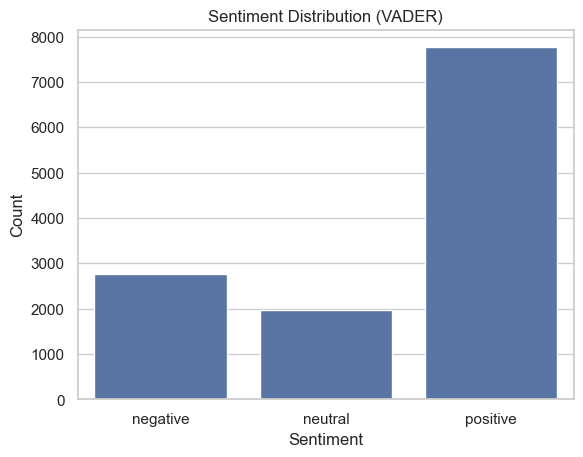

In [9]:
# how reviews spread across positive, negative, and neutral

sns.countplot(x="vader_sentiment", data=df, order=["negative","neutral","positive"])
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


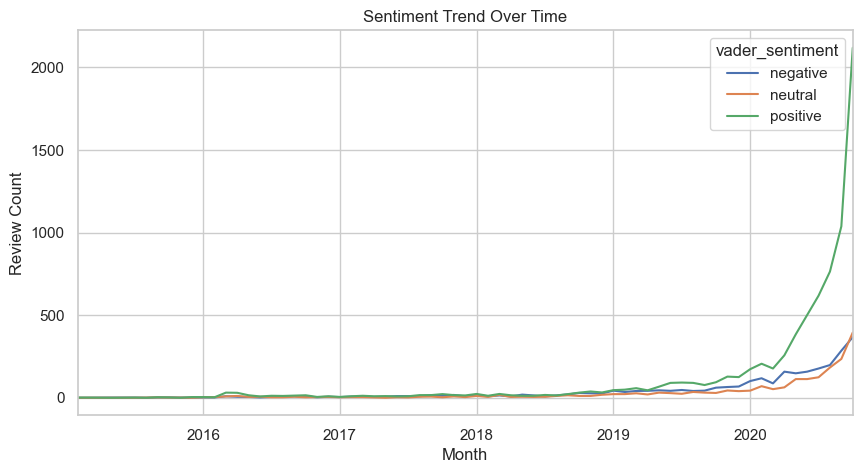

In [10]:
# show if negativity sentiments spike after an event/update

df["date"] = pd.to_datetime(df["at"]) 
sentiment_over_time = df.groupby([df["date"].dt.to_period("M"), "vader_sentiment"]).size().unstack().fillna(0)

sentiment_over_time.plot(kind="line", figsize=(10,5))
plt.title("Sentiment Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Review Count")
plt.show()


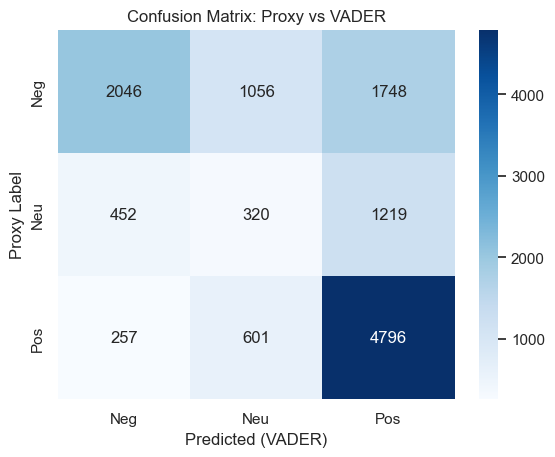

In [11]:
# compare labels vs vader

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(proxy, vader, labels=["negative","neutral","positive"])
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Neg","Neu","Pos"], yticklabels=["Neg","Neu","Pos"], cmap="Blues")
plt.xlabel("Predicted (VADER)")
plt.ylabel("Proxy Label")
plt.title("Confusion Matrix: Proxy vs VADER")
plt.show()


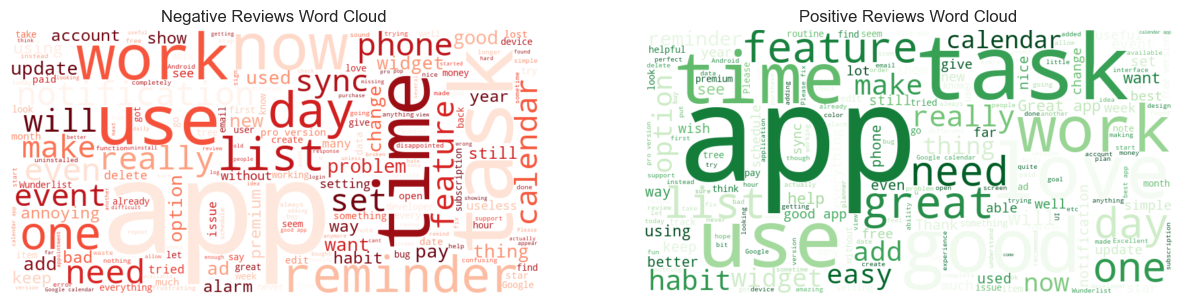

In [12]:
# highlight common words in negative vs psoitive feedback 

from wordcloud import WordCloud

neg_text = " ".join(df[df["vader_sentiment"]=="negative"]["content"].dropna())
pos_text = " ".join(df[df["vader_sentiment"]=="positive"]["content"].dropna())

wordcloud_neg = WordCloud(width=800, height=400, background_color="white", colormap="Reds").generate(neg_text)
wordcloud_pos = WordCloud(width=800, height=400, background_color="white", colormap="Greens").generate(pos_text)

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Reviews Word Cloud")

plt.subplot(1,2,2)
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Reviews Word Cloud")

plt.show()


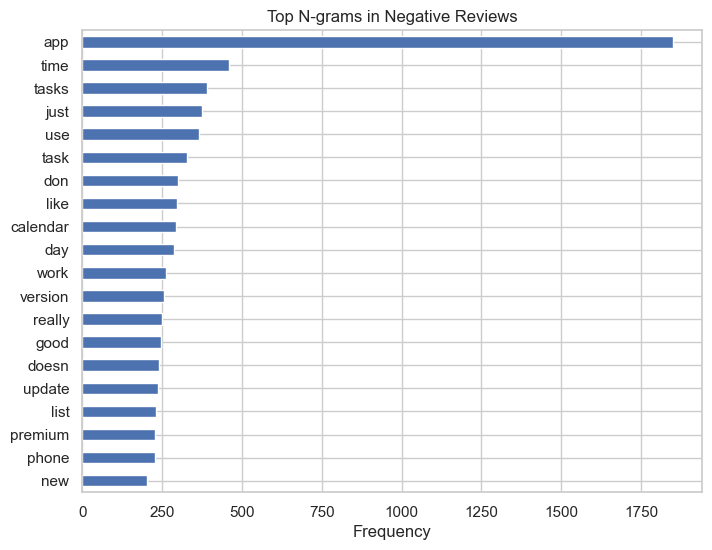

In [13]:
# top terms in negative reviews

from collections import Counter

vectorizer = CountVectorizer(ngram_range=(1,2), stop_words="english", max_features=20)
X = vectorizer.fit_transform(neg_reviews)
ngrams = dict(zip(vectorizer.get_feature_names_out(), X.sum(axis=0).A1))

top_ngrams = pd.Series(ngrams).sort_values(ascending=True).tail(20)
top_ngrams.plot(kind="barh", figsize=(8,6))
plt.title("Top N-grams in Negative Reviews")
plt.xlabel("Frequency")
plt.show()


## 5. Insights & Interpretation
- Which themes are driving negative feedback?
- Do proxy ratings align with actual sentiment?
- Any noticeable trends over time?


## 6. Deliverables
- Sentiment distributions (VADER vs Proxy)
- Confusion matrices
- N-gram charts / word clouds
- Topic keywords table
- Theme × sentiment cross-tab
